In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_parquet("../../cleaned_data.parquet")
df['resolution_hours'] = (df['Closed Date'] - df['Created Date']).dt.total_seconds() / 3600

In [41]:
zip_performance = df.groupby('Incident Zip')['resolution_hours'].agg(
    median_time='median',
    mean_time='mean',
    std_dev='std',
    count='count'
)

SLOW_THRESHOLD_HOURS = df['resolution_hours'].quantile(0.80)
slow_tickets = df[df['resolution_hours'] > SLOW_THRESHOLD_HOURS].groupby('Incident Zip').size()
total_tickets = df.groupby('Incident Zip').size()

pct_slow = (slow_tickets / total_tickets).fillna(0)
zip_performance['pct_slow_tickets'] = pct_slow

# # Ignore count with less than 50. Too less info to count it for a cluster
zip_performance = zip_performance[zip_performance['count'] >= 50]

OUTLIER_THRESHOLD = 100

outliers = zip_performance[zip_performance['median_time'] > OUTLIER_THRESHOLD]
df_clean = zip_performance[zip_performance['median_time'] <= OUTLIER_THRESHOLD].copy()

features = ['median_time', 'mean_time', 'std_dev','pct_slow_tickets']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean[features])
df_scaled = pd.DataFrame(
    df_scaled, 
    index=df_clean.index, 
    columns=features
)

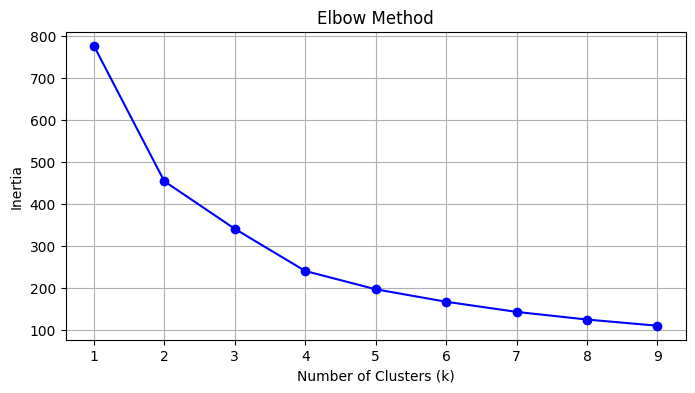

In [42]:
from utils import plot_elbow

plot_elbow(df_scaled)

In [49]:
from sklearn.cluster import KMeans

K = 4
print(f"\nRunning K-Means with K={K}...")
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Assign clusters back to the original (unscaled) dataframe
df_clean['Cluster'] = clusters

# 3. Interpret the Clusters
# We aggregate the *original* metrics to understand the profile of each cluster.
profile = df_clean.groupby('Cluster')[features].mean()

# Add 'Days' for easier reading
profile['median_days'] = profile['median_time'] / 24
profile['mean_days'] = profile['mean_time'] / 24
profile['count'] = df_clean.groupby('Cluster').size()

print("\n--- Cluster Performance Profiles ---")
# Sort by Median Time so Cluster 0 is likely the "Fastest" and last is "Slowest"
profile.sort_values('median_time').round(2)



Running K-Means with K=4...

--- Cluster Performance Profiles ---


,median_time,mean_time,std_dev,pct_slow_tickets,median_days,mean_days,count
Cluster,,,,,,,
1,2.90,96.47,353.34,0.15,0.12,4.02,88
0,6.94,218.40,686.25,0.24,0.29,9.10,37
2,7.98,131.05,394.19,0.24,0.33,5.46,65
3,30.28,374.00,798.91,0.39,1.26,15.58,4


--- Starting Map Generation ---
Calculating zip code centroids...
Loading map from ../../geo_data.geojson...
Performing spatial join...


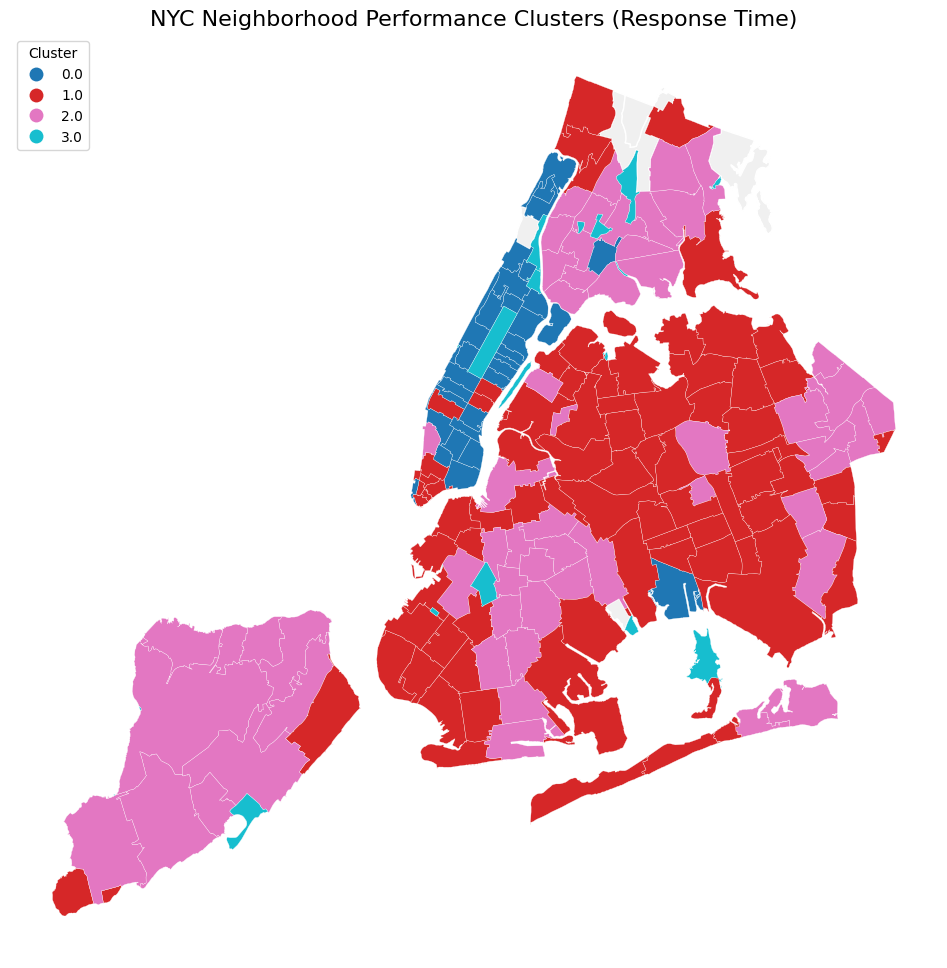

--- Map Generation Complete ---


In [50]:
from utils import plot_cluster_map

df_for_map = df_clean.reset_index()[['Incident Zip', 'Cluster']]

df_for_map['Cluster'].value_counts()

plot_cluster_map(
    df=df_for_map,
    title="NYC Neighborhood Performance Clusters (Response Time)"
)